In [1]:
import matplotlib.pyplot as plt
import os

In [2]:
# get the total energy from the OUTCAR file
def get_total_energy(outcar_file):
    with open(outcar_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'free  energy   TOTEN' in line:
                energy = float(line.split()[4])
                return energy
    return None

In [3]:
encuts = []
energies = []

subfolders = os.listdir("encut_convergence")
# sort the subfolders by encut value
subfolders.sort(key=lambda x: int(x.split("_")[1]))

for subfolder in subfolders:
    if subfolder.startswith("encut_"):
        encut_value = int(subfolder.split("_")[1])
        energy = get_total_energy(f'encut_convergence/{subfolder}/OUTCAR')
        print(f'ENCUT: {encut_value} eV, Total Energy: {energy} eV')
        if energy is not None:
            encuts.append(encut_value)
            energies.append(energy)

ENCUT: 300 eV, Total Energy: -103.35043183 eV
ENCUT: 350 eV, Total Energy: -103.30101807 eV
ENCUT: 400 eV, Total Energy: -103.35269139 eV
ENCUT: 450 eV, Total Energy: -103.35530289 eV
ENCUT: 500 eV, Total Energy: -103.33540649 eV
ENCUT: 600 eV, Total Energy: -103.34104292 eV
ENCUT: 700 eV, Total Energy: -103.35750992 eV
ENCUT: 800 eV, Total Energy: -103.36420032 eV


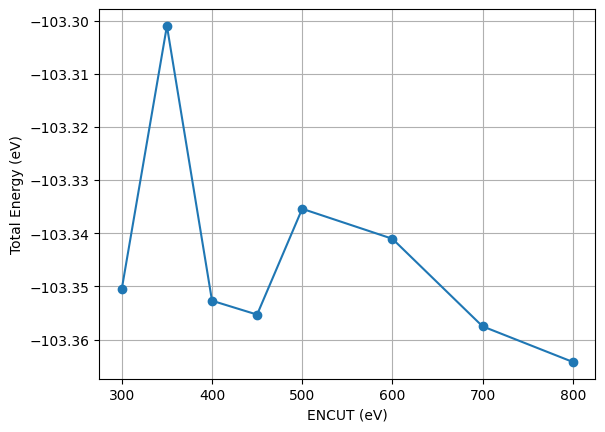

In [4]:
plt.plot(encuts, energies, marker='o')
plt.xlabel('ENCUT (eV)')
plt.ylabel('Total Energy (eV)')
plt.grid()

In [7]:
# kpoints convergence results
subfolders = os.listdir("kpoints_convergence")

kpoints = []
energies = []

# sort the subfolders by kpoints value
subfolders.sort(key=lambda x: int(x.split("_")[1]))

for subfolder in subfolders:
    if subfolder.startswith("kpoints_"):
        kpoints_value = int(subfolder.split("_")[1])
        energy = get_total_energy(f'kpoints_convergence/{subfolder}/OUTCAR')
        print(f'KPOINTS: {kpoints_value}x{kpoints_value}x{kpoints_value}, Total Energy: {energy} eV')
        if energy is not None:
            kpoints.append(kpoints_value)
            energies.append(energy)

KPOINTS: 1x1x1, Total Energy: -101.40023618 eV
KPOINTS: 2x2x2, Total Energy: -104.29912898 eV
KPOINTS: 3x3x3, Total Energy: -102.54864581 eV
KPOINTS: 4x4x4, Total Energy: -103.35043183 eV
KPOINTS: 5x5x5, Total Energy: -103.14843921 eV
KPOINTS: 6x6x6, Total Energy: -103.26907646 eV
KPOINTS: 7x7x7, Total Energy: -103.24416629 eV
KPOINTS: 8x8x8, Total Energy: -103.25985816 eV


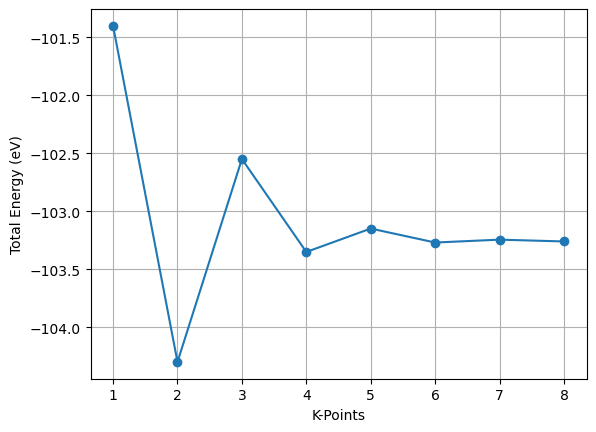

In [8]:
plt.plot(kpoints, energies, marker='o')
plt.xlabel('K-Points')
plt.ylabel('Total Energy (eV)')
plt.grid()